<a href="https://colab.research.google.com/github/debi201326/Shallow-and-Deep-Learning/blob/main/SDL_Practical_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing a Convolutional Neural Network for Image Classification: Distinguishing Between Dogs vs Cats.

In [11]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

In [12]:
(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

In [13]:
def augment(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def preprocess(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = ds_train.map(augment).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)


In [14]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3, min_lr=1e-6)

In [17]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.6350 - loss: 0.8270 - val_accuracy: 0.6922 - val_loss: 0.6104 - learning_rate: 3.0000e-04
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 51ms/step - accuracy: 0.7580 - loss: 0.5040 - val_accuracy: 0.7687 - val_loss: 0.4938 - learning_rate: 3.0000e-04
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.7923 - loss: 0.4570 - val_accuracy: 0.7696 - val_loss: 0.4781 - learning_rate: 3.0000e-04
Epoch 4/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - accuracy: 0.8152 - loss: 0.4126 - val_accuracy: 0.8293 - val_loss: 0.3799 - learning_rate: 3.0000e-04
Epoch 5/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.8433 - loss: 0.3716 - val_accuracy: 0.8147 - val_loss: 0.4187 - learning_rate: 3.0000e-04
Epoch 6/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.8622 - loss: 0.3311 - val_accuracy: 0.8439 - val_loss: 0.3673 - learning_rate: 3.0000e-04
Epoch 7/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 57ms/ste

In [18]:
loss, acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {acc*100:.2f}%")

146/146 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8904 - loss: 0.2791

Test Accuracy: 89.45%


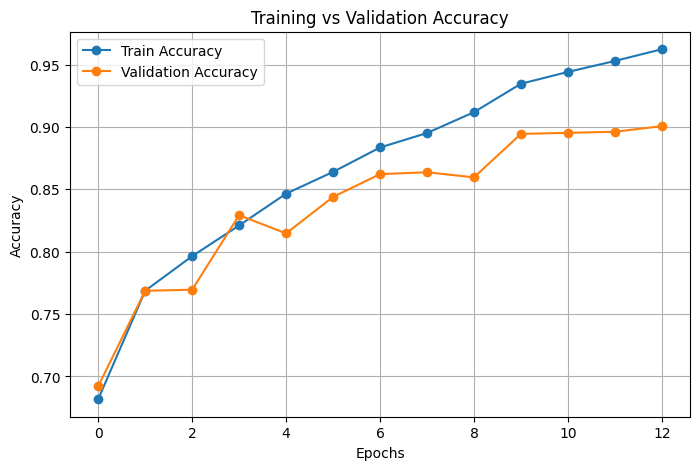

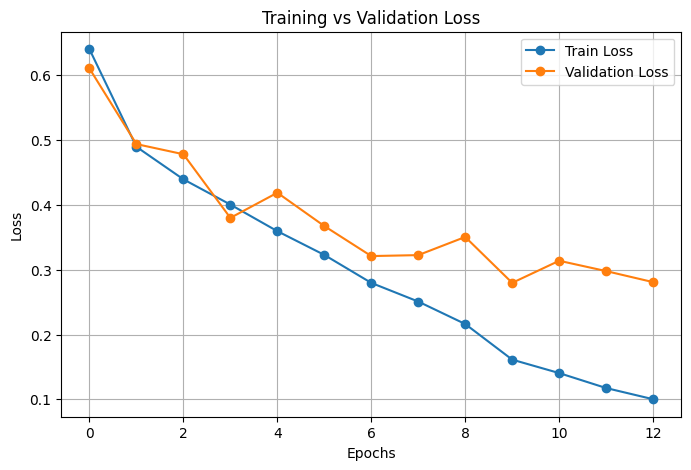

In [19]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step


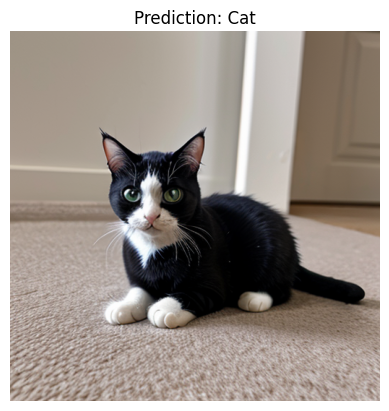

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


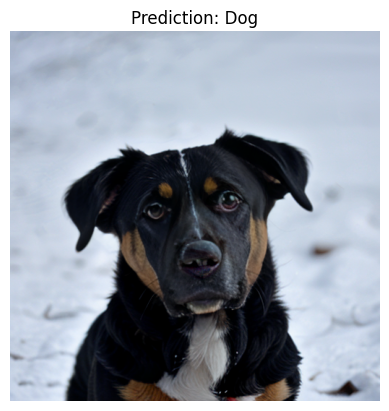

In [21]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    prediction = model.predict(img_array)
    class_name = "Dog" if prediction[0][0] > 0.5 else "Cat"

    plt.imshow(image.load_img(img_path))
    plt.title(f"Prediction: {class_name}")
    plt.axis('off')
    plt.show()


predict_image("/content/sample1.png")
predict_image("/content/sample2.png")